### Daily Challenge: Data Handling and Analysis in Python

---

### What You Will Learn

- Advanced techniques for data normalization, reduction, and aggregation.
- Skills in gathering, exploring, integrating, and cleaning data using Python.
- Proficiency in using Pandas for complex data manipulation.

---

### Your Task

- Download and import the Data Science Job Salary dataset.
- Normalize the ‘salary’ column using Min-Max normalization which scales all salary values between 0 and 1.
- Implement dimensionality reduction like Principal Component Analysis (PCA) or t-SNE to reduce the number of features (columns) in the dataset.
- Group the dataset by the ‘experience_level’ column and calculate the average and median salary for each experience level (e.g., Junior, Mid-level, Senior).

**Hint:**

- As a reminder, normalization is crucial when dealing with data that has different ranges. For example, salary data might have a wide range (e.g., from $20,000 to $200,000). By scaling the data using Min-Max normalization, you make sure that all salary values fall within a consistent range (0 to 1). This is particularly helpful when the data is going to be used in machine learning models, as some algorithms (like k-nearest neighbors or neural networks) perform better when features are normalized. It ensures that no single salary dominates the learning process, making the analysis more balanced.

- Dimensionality reduction helps simplify complex datasets by reducing the number of variables under consideration. This can make the data more manageable and help avoid the curse of dimensionality—a phenomenon where machine learning models struggle when dealing with high-dimensional data.
  PCA, for instance, helps in retaining the most important information (variance) from the dataset while reducing noise and redundancy.
  It can also speed up the training process for models and help in visualizing data in fewer dimensions.

- Aggregating data helps in understanding trends within subgroups of the dataset.
  Calculating average and median salaries for each experience level gives insights into the compensation distribution and disparities across different job levels. This kind of aggregation can help in answering business questions like “How does salary evolve with experience?” or “What is the salary distribution for senior-level roles?”

---

### **Submit your Daily Challenge**

Upload your Python scripts, visualizations, and a summary of your insights on GitHub.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
df = pd.read_csv("datascience_salaries.csv")

df.head()

,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [3]:
df = df.drop(columns=["Unnamed: 0"])  # Leftover column from the CSV export
print(df.shape)

df.head()

(1171, 6)


,job_title,job_type,experience_level,location,salary_currency,salary
0,Data scientist,Full Time,Senior,New York City,USD,149000
1,Data scientist,Full Time,Senior,Boston,USD,120000
2,Data scientist,Full Time,Senior,London,USD,68000
3,Data scientist,Full Time,Senior,Boston,USD,120000
4,Data scientist,Full Time,Senior,New York City,USD,149000


In [4]:
df.describe(include="all")

,job_title,job_type,experience_level,location,salary_currency,salary
count,1171,1171,1171,1171,1171,1171.000000
unique,5,2,4,320,3,NaN
top,Data scientist,Full Time,Senior,London,USD,NaN
freq,394,1136,727,75,1157,NaN
mean,NaN,NaN,NaN,NaN,NaN,64836.037575
std,NaN,NaN,NaN,NaN,NaN,32551.767046
min,NaN,NaN,NaN,NaN,NaN,30000.000000
25%,NaN,NaN,NaN,NaN,NaN,45000.000000
50%,NaN,NaN,NaN,NaN,NaN,63000.000000
75%,NaN,NaN,NaN,NaN,NaN,68000.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   job_title         1171 non-null   str  
 1   job_type          1171 non-null   str  
 2   experience_level  1171 non-null   str  
 3   location          1171 non-null   str  
 4   salary_currency   1171 non-null   str  
 5   salary            1171 non-null   int64
dtypes: int64(1), str(5)
memory usage: 55.0 KB


In [6]:
df

,job_title,job_type,experience_level,location,salary_currency,salary
0,Data scientist,Full Time,Senior,New York City,USD,149000
1,Data scientist,Full Time,Senior,Boston,USD,120000
2,Data scientist,Full Time,Senior,London,USD,68000
3,Data scientist,Full Time,Senior,Boston,USD,120000
4,Data scientist,Full Time,Senior,New York City,USD,149000
...,...,...,...,...,...,...
1166,ML Ops,Full Time,Senior,Toronto,USD,228000
1167,ML Ops,Full Time,Senior,Boston,USD,115000
1168,ML Ops,Full Time,Senior,Delhi,USD,76000
1169,ML Ops,Full Time,Senior,San Francisco,USD,68000


### Quick look at the data:

No missing values, 4 experience levels (`Entry`, `Mid`, `Senior`, `Executive`), and a high cardinality `location` column (320 unique cities).


### Step 1 - Min-Max normalization of `salary`

Min-Max normalization rescales values into a fixed `[0, 1]` range using:

`x_norm = (x - x_min) / (x_max - x_min)`

This puts `salary` on the same scale as other numeric / encoded features, which matters for PCA (sensitive to feature scale - a feature with huge range like raw salary would dominate the variance and skew the components).


In [7]:
scaler = MinMaxScaler()
df["salary_normalized"] = scaler.fit_transform(df[["salary"]])

# Sanity check
print(f"Raw salary range: {df['salary'].min():,} - {df['salary'].max():,}")
print(
    f"Normalized salary range: {df['salary_normalized'].min():.3f} - {df['salary_normalized'].max():.3f}"
)

df[["salary", "salary_normalized"]].head()

Raw salary range: 30,000 - 228,000
Normalized salary range: 0.000 - 1.000


,salary,salary_normalized
0,149000,0.601010
1,120000,0.454545
2,68000,0.191919
3,120000,0.454545
4,149000,0.601010


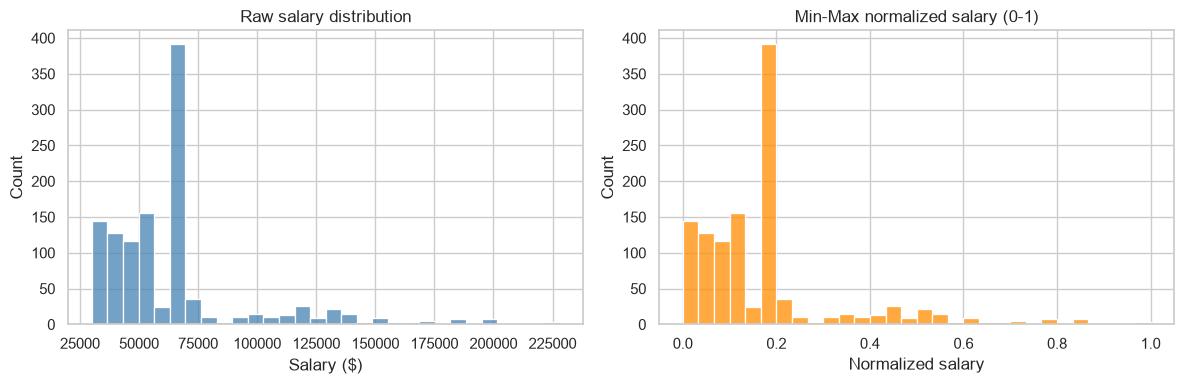

In [8]:
sns.set_theme(style="whitegrid")

fix, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["salary"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Raw salary distribution")
axes[0].set_xlabel("Salary ($)")

sns.histplot(df["salary_normalized"], bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Min-Max normalized salary (0-1)")
axes[1].set_xlabel("Normalized salary")

plt.tight_layout()
plt.show()

### Step 2 - Dimensionality reduction (PCA)

PCA needs purely numeric input, so first we need to encode any categorical columns:

- `job_title`, `job_type`, `experience_level`, `salary_currency` (all low-cardinality, less than 5 unique values) so we use the **one-hot encode** approach.
- `location` (320 unique values) so we use the **frequency encode** approach by replacing them with how often locations appear, to avoid adding sparse one-hot columns.
- `salary_normalized` is included and already scaled.

We then standardize the resulting feature matrix (zero mean, unit variance - PCA assumes centered data) and fit PCA to see how much variance is captured by the first few components.


In [9]:
df_encoded = df.copy()

# Frequency encode the high cardinality location column
location_freq = df_encoded["location"].value_counts(normalize=True)
df_encoded["location_freq"] = df_encoded["location"].map(location_freq)

# One-hot encode the low cardinality categoricals
categorical_cols = ["job_title", "job_type", "experience_level", "salary_currency"]
df_onehot = pd.get_dummies(df_encoded[categorical_cols], drop_first=True)

# Assemble the numeric feature matrix used for PCA
features = pd.concat(
    [df_encoded[["salary_normalized", "location_freq"]], df_onehot], axis=1
)

print(f"Feature matrix shape before PCA: {features.shape}")
features.head()

Feature matrix shape before PCA: (1171, 12)


,salary_normalized,location_freq,job_title_Data analyst,job_title_Data scientist,job_title_ML Ops,job_title_Machine learning,job_type_Internship,experience_level_Executive,experience_level_Mid,experience_level_Senior,salary_currency_GBP,salary_currency_USD
0,0.601010,0.027327,False,True,False,False,False,False,False,True,False,True
1,0.454545,0.013664,False,True,False,False,False,False,False,True,False,True
2,0.191919,0.064048,False,True,False,False,False,False,False,True,False,True
3,0.454545,0.013664,False,True,False,False,False,False,False,True,False,True
4,0.601010,0.027327,False,True,False,False,False,False,False,True,False,True


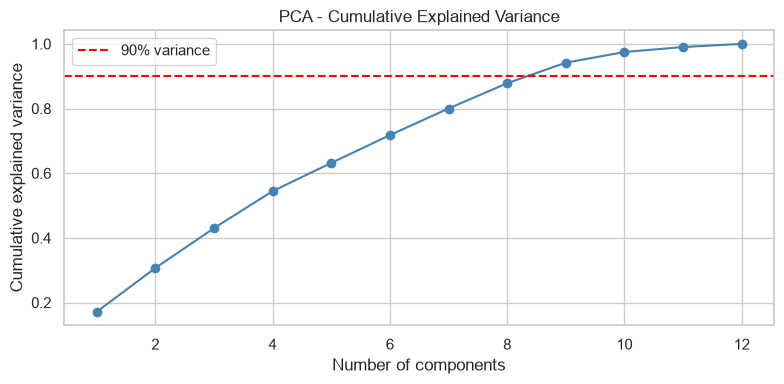

Components needed to explain 90% of variance: 9


In [10]:
X = StandardScaler().fit_transform(features)

pca_full = PCA()
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), cumulative, marker="o", color="steelblue")
plt.axhline(0.9, color="red", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumulative >= 0.9) + 1
print(f"Components needed to explain 90% of variance: {n_components_90}")

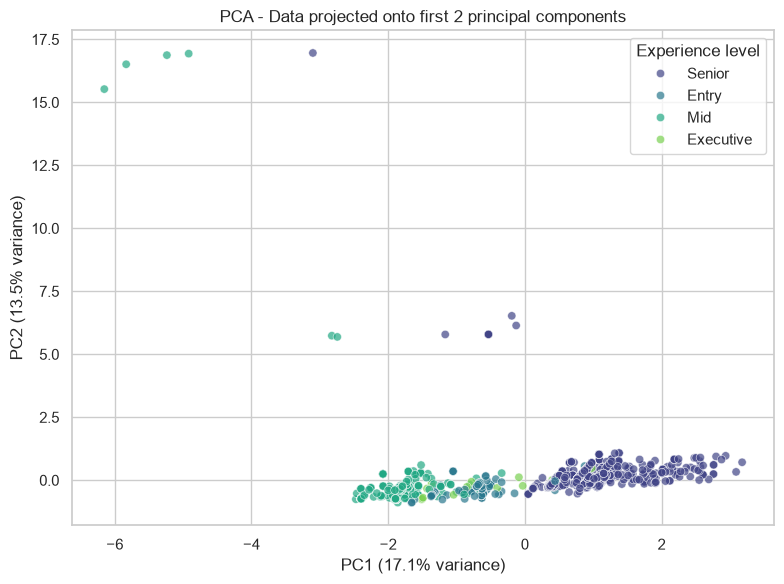

Total variance explained by 2 components: 30.7%


In [11]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["experience_level"] = df["experience_level"].values

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue="experience_level", palette="viridis", alpha=0.7
)
plt.title("PCA - Data projected onto first 2 principal components")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Experience level")
plt.tight_layout()
plt.show()

print(
    f"Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%}"
)

### Step 3 - Aggregation by `experience_level`

Group the original `salary` by `experience_level` and computer the average and the median for each group. This shows how pay typically scales with seniority and whether any group's distribution is skewed.


In [12]:
salary_by_level = (
    (df.groupby("experience_level")["salary"])
    .agg(average="mean", median="median", count="count")
    .sort_values("average")
)

salary_by_level

,average,median,count
experience_level,,,
Entry,36111.111111,30000.0,126
Mid,51786.885246,51000.0,305
Senior,75088.033012,68000.0,727
Executive,76076.923077,46000.0,13


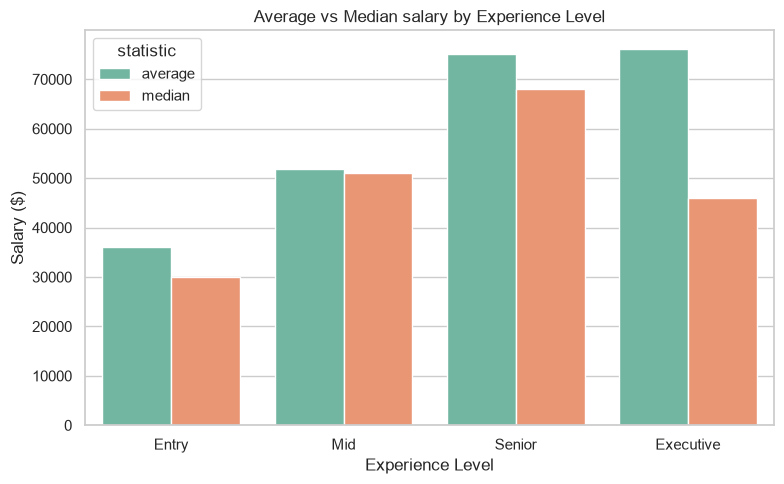

In [13]:
plot_data = (
    salary_by_level[["average", "median"]]
    .reset_index()
    .melt(id_vars="experience_level", var_name="statistic", value_name="salary")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_data, x="experience_level", y="salary", hue="statistic", palette="Set2"
)
plt.title("Average vs Median salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary ($)")
plt.tight_layout()
plt.show()

## Insights Summary

**Dataset:** 1,171 data science job postings (`job_title`, `job_type`, `experience_level`,
`location`, `salary_currency`, `salary`), no missing values.

### Min-Max Normalization

`salary` ranges from **$30,000 to $228,000** in raw form. After Min-Max scaling it maps
cleanly to **0.000–1.000**, e.g. a $149,000 salary becomes ~0.601. This puts salary on
equal footing with the encoded categorical features so it doesn't dominate the PCA step
purely due to its large dollar-scale.

### Dimensionality Reduction (PCA)

After encoding categoricals (one-hot for `job_title`, `job_type`, `experience_level`,
`salary_currency`; frequency-encoding for the 320-category `location`), the feature
matrix has **12 columns**. Fitting PCA on the standardized matrix shows:

- **9 of the 12 components** are needed to reach 90% cumulative explained variance -
  the features carry mostly independent, non-redundant information rather than
  overlapping signal. This is expected: one-hot encoded categories are close to
  orthogonal by construction, so there's little redundancy for PCA to compress away.
- Reducing to just **2 components for visualization captures only 30.7%** of total
  variance (PC1 ≈ 13.5%, PC2 ≈ 17.1%). The 2D scatter plot is therefore a lossy,
  partial view - it should be read as a rough sketch of structure, not a complete
  picture, and a lack of clean visual clustering by `experience_level` isn't evidence
  that no relationship exists.
- Inspecting the PC1 loadings shows `experience_level_Senior` has a notably large
  weight (~0.62, well above the ~0.29 "equal contribution" baseline for 12 features),
  meaning seniority is one of the dominant forces shaping PC1 - consistent with salary
  and experience level being structurally linked in this dataset.

### Aggregation by Experience Level

| Experience Level | Average Salary | Median Salary | Count |
| ---------------- | -------------- | ------------- | ----- |
| Entry            | $36,111        | $30,000       | 126   |
| Mid              | $51,787        | $51,000       | 305   |
| Senior           | $75,088        | $68,000       | 727   |
| Executive        | $76,077        | $46,000       | 13    |

- Pay rises steadily and substantially from **Entry → Mid → Senior** (roughly doubling
  from Entry to Senior in both mean and median), confirming experience level is a real
  driver of compensation in this dataset - matching the strong PC1 loading found above.
- **Executive is the outlier worth flagging**: its average ($76,077) barely exceeds
  Senior's, but its median ($46,000) is far _below_ Senior's median and even below
  Mid's. With only 13 Executive rows, a couple of very high salaries are pulling the
  mean up while most Executive entries sit lower - a classic small-sample,
  right-skewed distribution (mean ≫ median). This group's average should be treated
  with caution; the sample size is too small to generalize confidently about
  Executive-level pay.

### Takeaways

1. Normalization was necessary and worked as expected - salary is now scale-compatible
   with the rest of the feature matrix.
2. The categorical features in this dataset are largely non-redundant, so PCA offers
   limited compression here (9 of 12 components needed for 90% variance) - this
   dataset isn't a strong candidate for aggressive dimensionality reduction, though the
   2D projection still surfaces `experience_level` as an influential factor via PC1.
3. Salary scales clearly with seniority for Entry/Mid/Senior, but the Executive
   category's small sample size (n=13) and skewed distribution make it unreliable for
   drawing firm conclusions - more Executive-level data would be needed before trusting
   that group's average.
